# Data Pipeline & Baseline Results

This notebook covers:
1. Loading the Wefabricate dataset using `load_dataset()` from `support.py`
2. Exploring the dataset (class distribution, sample images, input dimensions)
3. Documenting preprocessing decisions
4. Loading the trained CNN and plotting baseline results
5. Reporting the highest accuracy before hyperparameter optimization

In [1]:
import json
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

%cd "WF-data and support code"

os.makedirs("../figures", exist_ok=True)

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

/Users/yousseftamer/Desktop/AI&ES year 1/DMAI/DMAI_assignment_2/WF-data and support code
device: mps


## 1. Dataset Loading

`support.py` provides `load_dataset()` which applies a fixed preprocessing pipeline and returns PyTorch `ImageFolder` datasets for train and test splits.

In [2]:
from support import load_dataset

train_dataset, test_dataset = load_dataset()

print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Classes       : {train_dataset.classes}")
print(f"Class-to-idx  : {train_dataset.class_to_idx}")

Train samples : 136
Test  samples : 34
Classes       : ['ng', 'ok']
Class-to-idx  : {'ng': 0, 'ok': 1}


## 2. Dataset Exploration

### 2.1 Class distribution

Train class distribution:
  ng: 68
  ok: 68

Test class distribution:
  ng: 17
  ok: 17


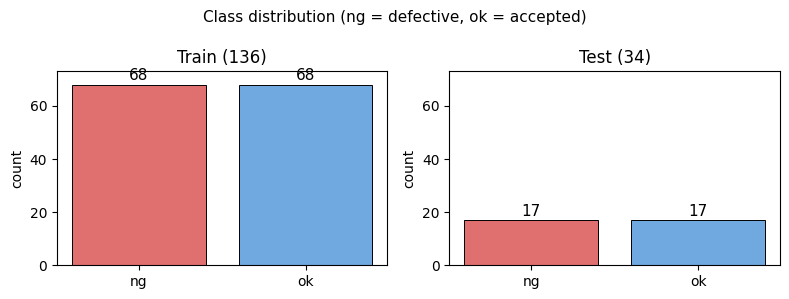

Saved figures/class_distribution.png


In [3]:
train_labels = [label for _, label in train_dataset]
test_labels  = [label for _, label in test_dataset]

class_names = train_dataset.classes  # ['ng', 'ok']

train_counts = [train_labels.count(i) for i in range(len(class_names))]
test_counts  = [test_labels.count(i)  for i in range(len(class_names))]

print("Train class distribution:")
for cls, cnt in zip(class_names, train_counts):
    print(f"  {cls}: {cnt}")

print("\nTest class distribution:")
for cls, cnt in zip(class_names, test_counts):
    print(f"  {cls}: {cnt}")

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, counts, title in zip(axes, [train_counts, test_counts], ["Train (136)", "Test (34)"]):
    bars = ax.bar(class_names, counts, color=["#e07070", "#70a8e0"], edgecolor="k", linewidth=0.7)
    ax.set_title(title)
    ax.set_ylabel("count")
    ax.set_ylim(0, max(max(train_counts), max(test_counts)) + 5)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, str(cnt),
                ha="center", va="bottom", fontsize=11)
plt.suptitle("Class distribution (ng = defective, ok = accepted)", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/class_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved figures/class_distribution.png")

### 2.2 Sample images

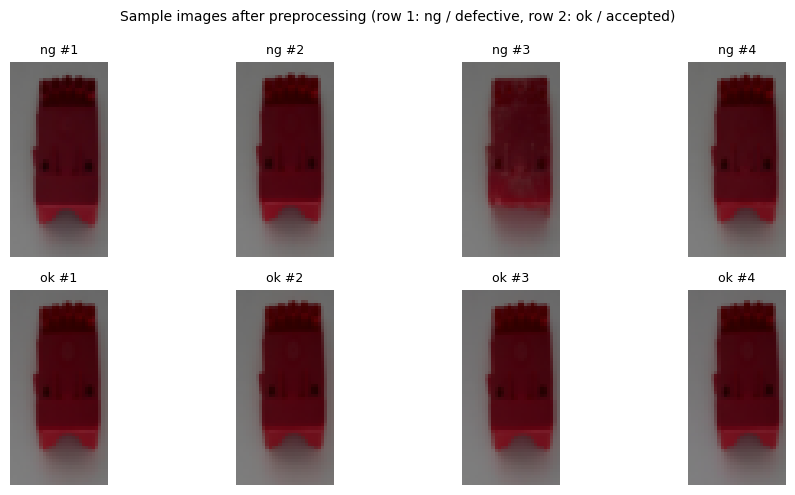

Saved figures/sample_images.png


In [4]:
random.seed(42)

ng_indices = [i for i, (_, lbl) in enumerate(train_dataset) if lbl == 0]
ok_indices = [i for i, (_, lbl) in enumerate(train_dataset) if lbl == 1]

sample_ng = random.sample(ng_indices, 4)
sample_ok = random.sample(ok_indices, 4)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for col, idx in enumerate(sample_ng):
    img, _ = train_dataset[idx]
    axes[0, col].imshow(img.permute(1, 2, 0).numpy())
    axes[0, col].axis("off")
    axes[0, col].set_title(f"ng #{col+1}", fontsize=9)

for col, idx in enumerate(sample_ok):
    img, _ = train_dataset[idx]
    axes[1, col].imshow(img.permute(1, 2, 0).numpy())
    axes[1, col].axis("off")
    axes[1, col].set_title(f"ok #{col+1}", fontsize=9)

plt.suptitle("Sample images after preprocessing (row 1: ng / defective, row 2: ok / accepted)", fontsize=10)
plt.tight_layout()
plt.savefig("../figures/sample_images.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved figures/sample_images.png")

### 2.3 Tensor shape and pixel statistics

In [5]:
sample_img, sample_lbl = train_dataset[0]
print(f"Tensor shape : {tuple(sample_img.shape)}  (C x H x W)")
print(f"Pixel range  : [{sample_img.min():.3f}, {sample_img.max():.3f}]")
print(f"Dtype        : {sample_img.dtype}")

Tensor shape : (3, 60, 30)  (C x H x W)
Pixel range  : [0.000, 0.494]
Dtype        : torch.float32


## 3. Preprocessing Decisions

The preprocessing pipeline in `support.py` applies three transforms sequentially:

| Step | Transform | Parameters | Rationale |
|------|-----------|------------|-----------|
| 1 | `Resize` | 105 × 78 px | Scales raw images to a common size while preserving aspect ratio |
| 2 | `CenterCrop` | 60 × 30 px | Crops to the informative central region of the front plate, removing background noise |
| 3 | `ToTensor` | — | Converts PIL image to float tensor in [0, 1]; channels-first layout required by PyTorch |

No mean/std normalisation is applied (pixels remain in [0, 1]). The dataset is too small (170 images) for reliable per-channel statistics, and the models still converge well without it.

No augmentation is used for the baseline run; the small dataset makes aggressive augmentation risky without proper cross-validation.

## 4. Baseline Results

The CNN was trained and the model weights (`model_before_tuning.pth`) and epoch-by-epoch training history (`training_history.json`) were saved. We load both here to plot the results.

In [6]:
class CNN(nn.Module):
    """VGG-style CNN for Wefabricate binary classification."""
    def __init__(self):
        super().__init__()
        self.conv1a = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool    = nn.MaxPool2d(2)
        self.relu    = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(64 * 15 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2     = nn.Linear(128, 2)

    def forward(self, x):
        x = self.relu(self.conv1a(x))
        x = self.relu(self.conv1b(x))
        x = self.pool(x)
        x = self.relu(self.conv2a(x))
        x = self.relu(self.conv2b(x))
        x = self.pool(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# Load saved weights
model = CNN().to(device)
model.load_state_dict(torch.load("../model_before_tuning.pth", map_location=device))
model.eval()
print("Loaded model_before_tuning.pth")

# Load training history
with open("../training_history.json") as f:
    history = json.load(f)

train_loss_hist = history["train_loss"]
train_acc_hist  = history["train_acc"]
test_loss_hist  = history["test_loss"]
test_acc_hist   = history["test_acc"]
EPOCHS = len(train_loss_hist)
print(f"History loaded: {EPOCHS} epochs")

Loaded model_before_tuning.pth
History loaded: 30 epochs


## 5. Learning Curves

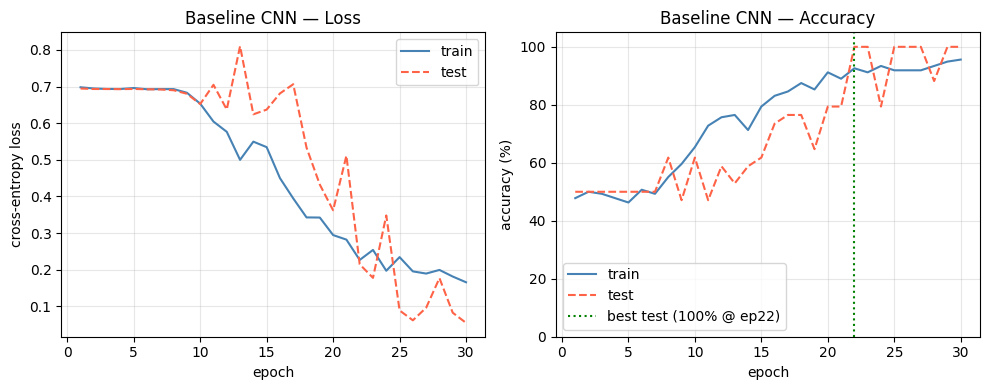

Saved figures/baseline_learning_curves.png


In [7]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Loss curve
ax1.plot(epochs_range, train_loss_hist, label="train", color="steelblue")
ax1.plot(epochs_range, test_loss_hist,  label="test",  color="tomato", linestyle="--")
ax1.set_xlabel("epoch")
ax1.set_ylabel("cross-entropy loss")
ax1.set_title("Baseline CNN — Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(epochs_range, [a * 100 for a in train_acc_hist], label="train", color="steelblue")
ax2.plot(epochs_range, [a * 100 for a in test_acc_hist],  label="test",  color="tomato", linestyle="--")
best_epoch = int(np.argmax(test_acc_hist)) + 1
best_acc   = max(test_acc_hist) * 100
ax2.axvline(best_epoch, color="green", linestyle=":", linewidth=1.5, label=f"best test ({best_acc:.0f}% @ ep{best_epoch})")
ax2.set_xlabel("epoch")
ax2.set_ylabel("accuracy (%)")
ax2.set_title("Baseline CNN — Accuracy")
ax2.set_ylim(0, 105)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/baseline_learning_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved figures/baseline_learning_curves.png")

## 6. Baseline Results Summary

In [8]:
best_test_acc   = max(test_acc_hist)
best_test_epoch = int(np.argmax(test_acc_hist)) + 1
final_test_acc  = test_acc_hist[-1]
final_train_acc = train_acc_hist[-1]

print("=" * 45)
print("       BASELINE RESULTS (before HPO)")
print("=" * 45)
print(f"  Epochs trained        : {EPOCHS}")
print(f"  Final train accuracy  : {final_train_acc*100:.1f}%")
print(f"  Final test  accuracy  : {final_test_acc*100:.1f}%")
print(f"  Best  test  accuracy  : {best_test_acc*100:.1f}%  (epoch {best_test_epoch})")
print("=" * 45)

       BASELINE RESULTS (before HPO)
  Epochs trained        : 30
  Final train accuracy  : 95.6%
  Final test  accuracy  : 100.0%
  Best  test  accuracy  : 100.0%  (epoch 22)
